In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 50

In [2]:
import scanpy as sc
from scipy.sparse import csr_matrix

from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina._spatial_utils import spatial_neighbors
from cellina import CellinaModel

In [3]:
# adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")
# adata.var.index = adata.var['gene_name-new']
# domains_key = "region"
# labels_key = 'cell_type'

In [4]:
adata = sc.read(
    f"../../data/crc_wt_cosmx/crc_202.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [5]:
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 44834896 stored elements and shape (420694, 2000)>

In [6]:
# sc.pl.spatial(adata, color=[domains_key, labels_key], spot_size=50)

In [7]:
n_neighbors = 10 #NOTE: @Moeed this is an important hyperparameter, which controls how smooth s is + how much ram it consumes. 
# 10 is a good default option
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [8]:
CellinaModel.setup_anndata(adata,
                           batch_key=None,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           layer='counts',
                           spatial_connectivities_key='spatial_connectivities'
                           )
model = CellinaModel(adata,
                     n_latent=20,
                     classifier_lambda=5,
                     discriminator_lambda=5,
                     link_prediction_weight=0, # NOTE Not sure if this is needed, nor if it works when combined with the other losses...
                     condition_on_intrinsic=False
                     )

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [9]:
model.train(max_epochs=30,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=5,
            early_stopping_monitor='validation_loss',
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.0001,
                         'weight_decay': 0.0001,
                         'normalize_losses': True,
                        #  "scale_adversarial_loss": "normalized"
                         },
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=512,
            devices=[1]
            )

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.p

Training:   0%|          | 0/30 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 5617. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 5588. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 5592. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78

In [10]:
list(model.history_.keys())

['validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'vae_loss_validation',
 'classifier_loss_raw_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'fool_loss_raw_validation',
 'fool_loss_validation',
 'fool_accuracy_validation',
 'edge_prediction_loss_validation',
 'edge_prediction_accuracy_validation',
 'discriminator_loss_validation',
 'discriminator_accuracy_validation',
 'ema_vae_init',
 'ema_clf_init',
 'ema_fool_init',
 'ema_edge_init',
 'discriminator_loss_train',
 'discriminator_accuracy_train',
 'train_loss',
 'scale_classifier_train',
 'scale_fool_train',
 'scale_edge_train',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'vae_loss_train',
 'classifier_loss_raw_train',
 'classifier_loss_train',
 'classifier_accuracy_train',
 'fool_loss_raw_train',
 'fool_loss_train',
 'fool_accuracy_train',
 'edge_prediction_loss_train',
 'edge_predictio

<Axes: xlabel='epoch'>

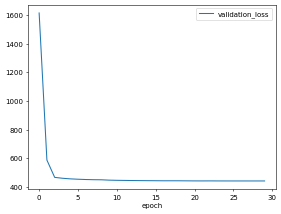

In [11]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

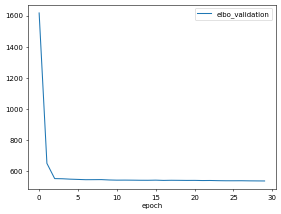

In [12]:
model.history_['elbo_validation'].plot()

<Axes: xlabel='epoch'>

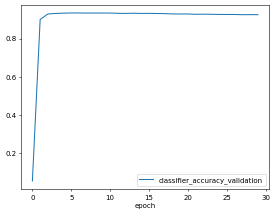

In [13]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

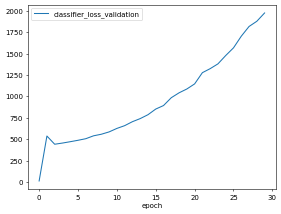

In [14]:
model.history_['classifier_loss_validation'].plot()

<Axes: xlabel='epoch'>

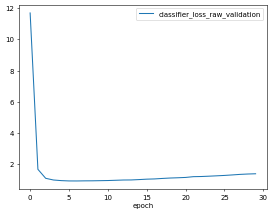

In [15]:
model.history_['classifier_loss_raw_validation'].plot()

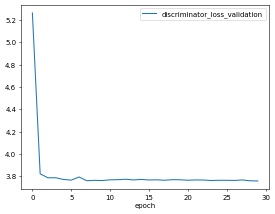

In [16]:
if 'discriminator_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['discriminator_loss_validation'].plot()

In [17]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'edge_prediction_accuracy_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'ema_edge_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'scale_classifier_train', 'scale_fool_train', 'scale_edge_train', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train', 'edge_prediction_accuracy_train'])

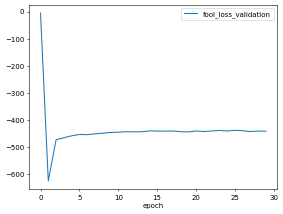

In [18]:
if 'fool_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_validation'].plot()

<Axes: xlabel='epoch'>

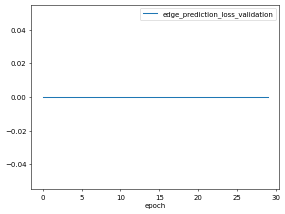

In [19]:
model.history_['edge_prediction_loss_validation'].plot()

In [20]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'edge_prediction_accuracy_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'ema_edge_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'scale_classifier_train', 'scale_fool_train', 'scale_edge_train', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train', 'edge_prediction_accuracy_train'])

<Axes: xlabel='epoch'>

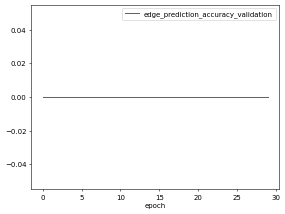

In [21]:
model.history_['edge_prediction_accuracy_validation'].plot() # NOTE: makes sense that it's not very high, since the graph is very sparse and very large.

In [22]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


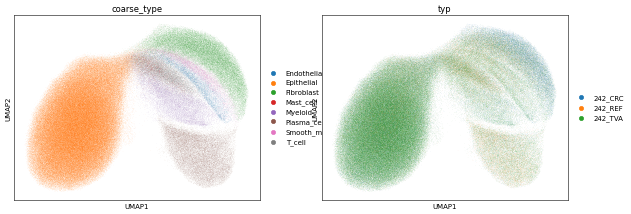

In [23]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key])

In [24]:
adata.obsm['z'].max()

np.float32(7.2516675)

In [25]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [26]:
adata.obsm['s'].max()

np.float32(4.887195)

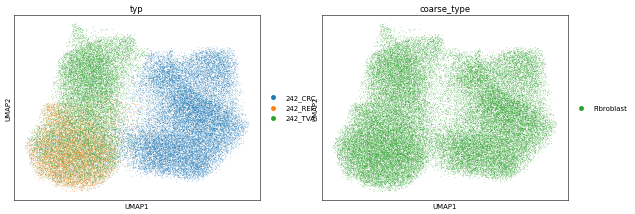

In [27]:
fib_adata = adata[adata.obs[labels_key]=='Fibroblast']
sc.pp.neighbors(fib_adata, use_rep='s')
sc.tl.umap(fib_adata)
sc.pl.umap(fib_adata, color=[domains_key, labels_key])

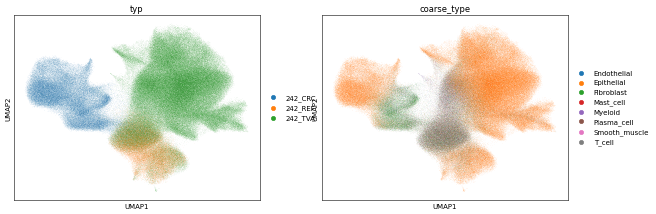

In [28]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[domains_key, labels_key])

In [29]:
# Counterfactual: fibroblasts in TVA with CRC neighbours
seed_mask = (adata.obs[labels_key] == 'Fibroblast') & (adata.obs[domains_key] == '242_TVA')
nbr_mask  = adata.obs[domains_key] == '242_CRC'

seed_idx = np.where(seed_mask)[0]
nbr_idx  = np.where(nbr_mask)[0]

cf_s = model.get_counterfactual_latents(
    seed_idx, nbr_idx,
    n_neighbors_per_seed=10,
    latent_key='s',
    batch_size=512,
)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


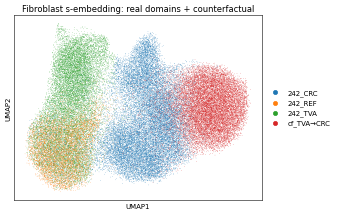

In [30]:
import anndata as ad

# Subset real fibroblasts from each domain
fib_tva = adata[seed_mask].copy()
fib_crc = adata[(adata.obs[labels_key] == 'Fibroblast') & (adata.obs[domains_key] == '242_CRC')].copy()
fib_ref = adata[(adata.obs[labels_key] == 'Fibroblast') & (adata.obs[domains_key] == '242_REF')].copy()

# Build counterfactual anndata (same cells as fib_tva, but with cf spatial embedding)
fib_cf = fib_tva.copy()
fib_cf.obs[domains_key] = 'cf_TVA→CRC'
fib_cf.obsm['s'] = cf_s

# Concatenate
combined = ad.concat([fib_tva, fib_crc, fib_ref, fib_cf])

# UMAP on s representation
sc.pp.neighbors(combined, use_rep='s')
sc.tl.umap(combined)
sc.pl.umap(combined, color=[domains_key], title='Fibroblast s-embedding: real domains + counterfactual')

In [31]:
def spatial_coherence_score(X, labels, k=5):
    X = np.asarray(X)
    labels = np.asarray(labels)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # exclude each point itself (indices[:,0])
    indices = indices[:, 1:]
    
    same_cluster_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    scs = np.mean(same_cluster_counts / k)
    return scs


In [ ]:
# Nearest Neighbours and Leiden Clustering
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata, neighbors_key='neighbors')
sc.tl.leiden(adata, key_added='leiden_s', resolution=0.4)

/tmp/ipykernel_2569078/4127518302.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='leiden_s', resolution=0.4)


In [ ]:
spatial_coherence_score(adata.obsm['spatial'], adata.obs['leiden_s'], k=n_neighbors) # NOTE: most sensible metric imho
# NOTE: worse than when using spatial_x

np.float64(0.6814147575197174)

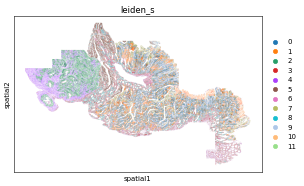

In [ ]:
sc.pl.spatial(adata, color=['leiden_s'], spot_size=50)

In [ ]:
def compute_spatial_metrics(adata, label_key: str, coord_key: str = 'spatial', exclude_labels=None) -> float:
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
    import pandas as pd
    from scipy.spatial.distance import pdist, squareform

    adata.obs[label_key] = adata.obs[label_key].astype('category')
    
    if exclude_labels is not None:
        mask = ~adata.obs[label_key].isin(exclude_labels)
        ad = adata[mask].copy()
    else:
        ad = adata

    labels = ad.obs[label_key].cat.codes.values
    spatial_coords = ad.obsm[coord_key]

    mean_asw = silhouette_score(X=spatial_coords, labels=labels, metric='euclidean')
    db_score = davies_bouldin_score(X=spatial_coords, labels=labels)
    ch_score = calinski_harabasz_score(X=spatial_coords, labels=labels)
    
    samples_asw = silhouette_samples(X=spatial_coords, labels=labels, metric='euclidean')
    
    df = pd.DataFrame(index=ad.obs_names, data={f'spatial_asw_{label_key}': samples_asw})
    asw_by_label = df.groupby(ad.obs[label_key])[f'spatial_asw_{label_key}'].mean().round(3)
    asw_by_label.index.name = label_key
    asw_by_label = asw_by_label.to_dict()
    
    global_scores = {
        'asw ↑': round(mean_asw, 3),
        'db_score ↓': round(db_score, 3),
        'ch_score ↑': round(ch_score, 3)
    }
    
    return global_scores, asw_by_label

In [ ]:
# compute_spatial_metrics(adata, label_key='leiden_s', coord_key='spatial') # NOTE: takes forever